In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('iris.csv')

In [ ]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
df_ = df.copy()

In [ ]:
df_ = df_.drop('species', axis=1)

In [ ]:
df_.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scale = StandardScaler()

In [ ]:
scale_df_ = scale.fit_transform(df_)

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
k = range(1, 10)

In [ ]:
inertias = []

In [ ]:
for val in k:
  model = KMeans(n_clusters=val, random_state=42)
  model.fit(scale_df_)
  inertias.append(model.inertia_)

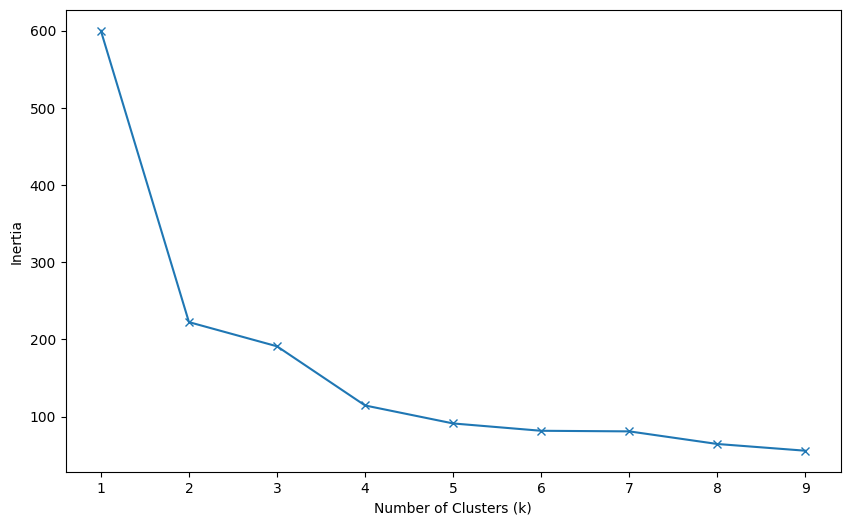

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(k, inertias, marker='x')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia');

In [ ]:
from kneed import KneeLocator

In [ ]:
k1 = KneeLocator(k, inertias, curve='convex', direction='decreasing')

In [ ]:
k1.elbow

np.int64(4)

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)

In [ ]:
y_pred = kmeans.fit_predict(scale_df_)

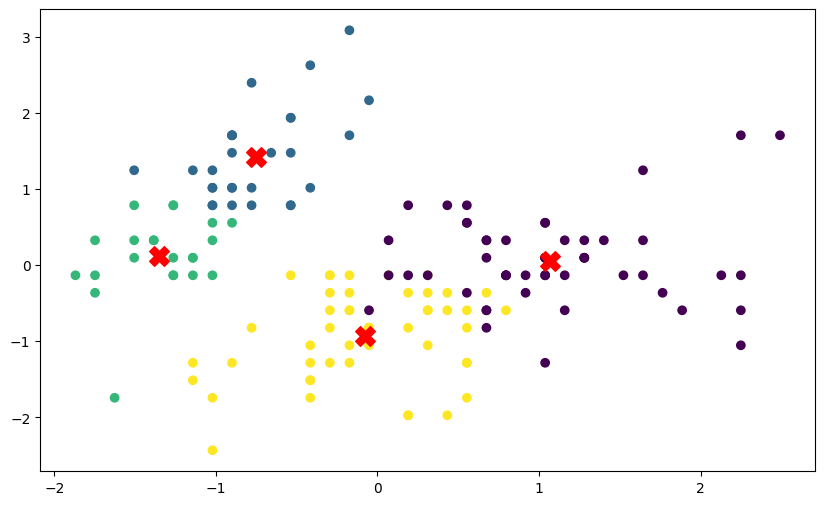

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(scale_df_[:, 0], scale_df_[:, 1], c=y_pred, cmap='viridis', marker='o')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='X', s=200, color='red', label='Centroides');

In [ ]:
from sklearn.metrics import silhouette_score

In [ ]:
silhouette_score(scale_df_, y_pred)

np.float64(0.3850454053045392)

#Isolationforest

In [ ]:
from sklearn.ensemble import IsolationForest

In [ ]:
contaminations = np.linspace(0.01, 0.1, 10)
scores_moyens = []

In [ ]:
df_ = df_.dropna()
df_ = df_.select_dtypes(include=[np.number])

In [ ]:
for val in contaminations:
    iso = IsolationForest(n_estimators=100, contamination=val, random_state=42)
    iso.fit(df_)
    scores = iso.score_samples(df_)
    scores_moyens.append(scores.mean())

In [ ]:
resultats = pd.DataFrame({
    'contamination': contaminations,
    'score_moyen': scores_moyens
})

In [ ]:
best_row = resultats.loc[resultats['score_moyen'].idxmax()]
best_contamination = best_row['contamination']
best_score = best_row['score_moyen']

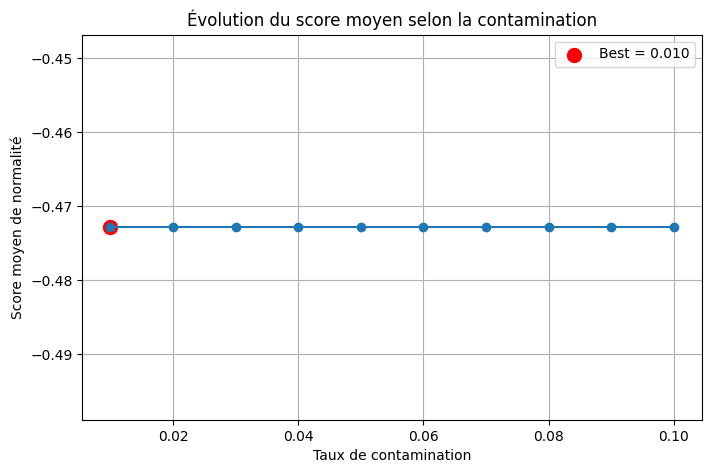

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(contaminations, scores_moyens, marker='o')
plt.title("Évolution du score moyen selon la contamination")
plt.xlabel("Taux de contamination")
plt.ylabel("Score moyen de normalité")
plt.grid(True)
# Marquer le meilleur point
plt.scatter(best_contamination, best_score, color='red', s=100, label=f"Best = {best_contamination:.3f}")
plt.legend()
plt.show()

In [ ]:
print(" Résultats :")
print(resultats)
print(f"Meilleur taux de contamination : {best_contamination} avec un score moyen de {best_score}")


 Résultats :
   contamination  score_moyen
0           0.01    -0.472833
1           0.02    -0.472833
2           0.03    -0.472833
3           0.04    -0.472833
4           0.05    -0.472833
5           0.06    -0.472833
6           0.07    -0.472833
7           0.08    -0.472833
8           0.09    -0.472833
9           0.10    -0.472833
Meilleur taux de contamination : 0.01 avec un score moyen de -0.4728331345002941


In [ ]:
model_iso = IsolationForest(n_estimators=100, contamination=0.010, random_state=42)

In [ ]:
y_pred_iso = model_iso.fit_predict(df_)

In [ ]:
anomalie = df_[y_pred_iso == -1]

In [ ]:
normal = df_[y_pred_iso == 1]

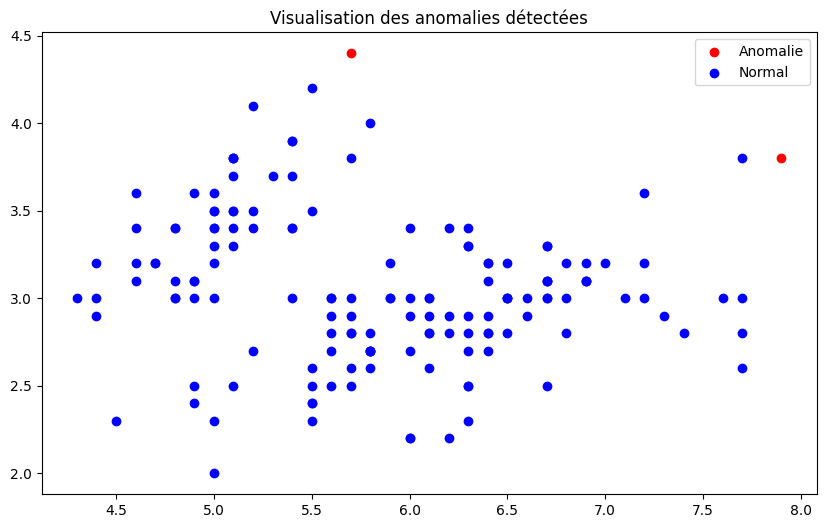

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(anomalie.iloc[:, 0], anomalie.iloc[:, 1], c='red', label='Anomalie')
plt.scatter(normal.iloc[:, 0], normal.iloc[:, 1], c='blue', label='Normal')
plt.title("Visualisation des anomalies détectées")
plt.legend()
plt.show()

In [ ]:
anomalie

,sepal_length,sepal_width,petal_length,petal_width
15,5.7,4.4,1.5,0.4
131,7.9,3.8,6.4,2.0


In [ ]:
normal

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3
